# 06 — Hyperparameter Tuning: Classification (RF and SVM)

**Input:** `data/processed/btk_fps.csv`  
**Output:** tuned models in `models/`, comparison in `results/`

Baseline performance from notebook 04 (default hyperparameters):
- Random Forest — Test AUC: 0.953
- SVM — Test AUC: 0.938

Goal: search for hyperparameter combinations that improve on these baselines,
using `class_weight='balanced'` throughout to address the 82.5/17.5 class imbalance.

Steps:
1. Load data, recreate the same train/test split as notebook 04
2. GridSearchCV for Random Forest
3. RandomizedSearchCV for SVM (faster than full grid for this model)
4. Compare tuned vs baseline performance
5. Final test set evaluation of tuned models
6. Save tuned models

## 1. Imports and Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report

INPUT_PATH = '../data/processed/btk_fps.csv'
RANDOM_STATE = 42

df = pd.read_csv(INPUT_PATH)
bit_cols = [c for c in df.columns if c.startswith('bit_')]

X = df[bit_cols].values
y = df['activity'].values

# Same split as notebook 04 — same random_state ensures identical train/test sets,
# so tuned results are directly comparable to the baseline.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Train set: {X_train.shape[0]} molecules')
print(f'Test set:  {X_test.shape[0]} molecules')

Train set: 3483 molecules
Test set:  871 molecules


## 2. Random Forest — GridSearchCV

Searching over `n_estimators`, `max_depth`, `min_samples_leaf`.  
3 × 3 × 3 = 27 combinations × 5 folds = 135 fits. RF is fast, so this is feasible.

In [2]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_grid = GridSearchCV(
    rf_base,
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print('Running GridSearchCV for Random Forest (27 combinations x 5 folds)...')
start = time.time()
rf_grid.fit(X_train, y_train)
elapsed = time.time() - start

print(f'\nDone in {elapsed:.1f}s')
print(f'Best params: {rf_grid.best_params_}')
print(f'Best CV AUC: {rf_grid.best_score_:.3f}')

Running GridSearchCV for Random Forest (27 combinations x 5 folds)...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Done in 157.5s
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV AUC: 0.941


## 3. SVM — RandomizedSearchCV

Searching over `C` and `gamma`. Using `RandomizedSearchCV` with 15 sampled
combinations instead of the full 4 × 4 = 16 grid — at this size the savings
are small, but this pattern matters more as the search space grows, and it
keeps SVM's slower training time manageable.

In [3]:
vm_param_dist = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.001, 0.01, 0.1]
}

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE
    ))
])

svm_search = RandomizedSearchCV(
    svm_pipeline,
    param_distributions=svm_param_dist,
    n_iter=15,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

print('Running RandomizedSearchCV for SVM (15 sampled combinations x 5 folds)...')
print('This may take several minutes...')
start = time.time()
svm_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f'\nDone in {elapsed:.1f}s')
print(f'Best params: {svm_search.best_params_}')
print(f'Best CV AUC: {svm_search.best_score_:.3f}')

Running RandomizedSearchCV for SVM (15 sampled combinations x 5 folds)...
This may take several minutes...
Fitting 5 folds for each of 15 candidates, totalling 75 fits


c:\Users\Giovanna\miniconda3\envs\qsar-proj1\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Done in 1756.2s
Best params: {'svc__gamma': 'scale', 'svc__C': 1}
Best CV AUC: 0.920


## 4. Compare Tuned vs Baseline (Cross-Validation AUC)

=== CV AUC: Baseline vs Tuned ===
               Baseline (default params)  Tuned (GridSearch/RandomizedSearch)
Random Forest                      0.941                                0.941
SVM                                0.920                                0.920


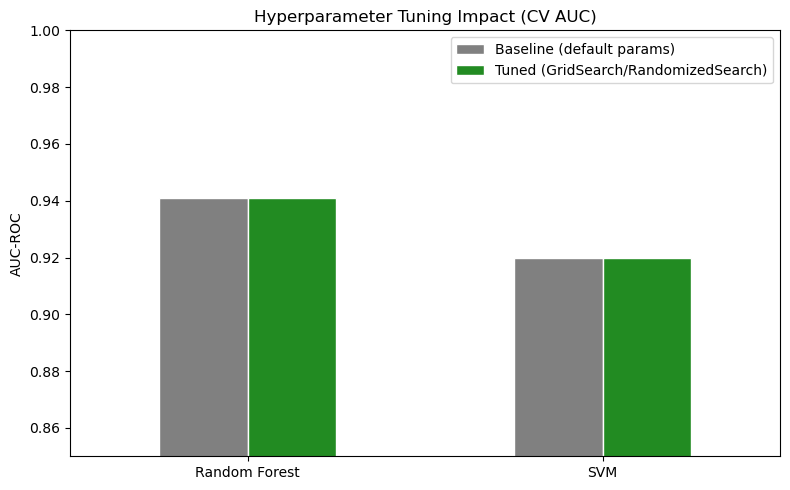

Plot saved to results/


In [4]:
# Baseline values from notebook 04 (hardcoded for comparison)
baseline_rf_cv_auc  = 0.941
baseline_svm_cv_auc = 0.920

comparison = pd.DataFrame({
    'Baseline (default params)': [baseline_rf_cv_auc, baseline_svm_cv_auc],
    'Tuned (GridSearch/RandomizedSearch)': [rf_grid.best_score_, svm_search.best_score_]
}, index=['Random Forest', 'SVM'])

print('=== CV AUC: Baseline vs Tuned ===')
print(comparison.round(3))

comparison.plot(kind='bar', figsize=(8, 5), color=['gray', 'forestgreen'], edgecolor='white')
plt.title('Hyperparameter Tuning Impact (CV AUC)')
plt.ylabel('AUC-ROC')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.savefig('../results/06_tuning_impact.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 5. Final Test Set Evaluation — Tuned Models

In [5]:
rf_best  = rf_grid.best_estimator_
svm_best = svm_search.best_estimator_

rf_pred  = rf_best.predict(X_test)
rf_proba = rf_best.predict_proba(X_test)[:, 1]

svm_pred  = svm_best.predict(X_test)
svm_proba = svm_best.predict_proba(X_test)[:, 1]

def print_test_metrics(name, y_true, y_pred, y_proba):
    auc = roc_auc_score(y_true, y_proba)
    f1  = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall    = recall_score(y_true, y_pred)
    print(f'=== {name} (tuned) \u2014 Test Set Performance ===')
    print(f'AUC-ROC:   {auc:.3f}')
    print(f'F1-score:  {f1:.3f}')
    print(f'Precision: {precision:.3f}')
    print(f'Recall:    {recall:.3f}')
    print()
    print(classification_report(y_true, y_pred, target_names=['Inactive', 'Active']))
    print()
    return auc, f1

rf_tuned_auc, rf_tuned_f1   = print_test_metrics('Random Forest', y_test, rf_pred, rf_proba)
svm_tuned_auc, svm_tuned_f1 = print_test_metrics('SVM', y_test, svm_pred, svm_proba)

=== Random Forest (tuned) — Test Set Performance ===
AUC-ROC:   0.953
F1-score:  0.941
Precision: 0.954
Recall:    0.928

              precision    recall  f1-score   support

    Inactive       0.70      0.79      0.74       152
      Active       0.95      0.93      0.94       719

    accuracy                           0.90       871
   macro avg       0.83      0.86      0.84       871
weighted avg       0.91      0.90      0.91       871


=== SVM (tuned) — Test Set Performance ===
AUC-ROC:   0.938
F1-score:  0.930
Precision: 0.943
Recall:    0.918

              precision    recall  f1-score   support

    Inactive       0.65      0.74      0.69       152
      Active       0.94      0.92      0.93       719

    accuracy                           0.89       871
   macro avg       0.80      0.83      0.81       871
weighted avg       0.89      0.89      0.89       871




## 6. Save Tuned Models

In [6]:
joblib.dump(rf_best, '../models/rf_btk_classifier_tuned.pkl')
joblib.dump(svm_best, '../models/svm_btk_classifier_tuned.pkl')

print('Tuned models saved:')
print('  models/rf_btk_classifier_tuned.pkl')
print('  models/svm_btk_classifier_tuned.pkl')

print(f'\nBest RF params:  {rf_grid.best_params_}')
print(f'Best SVM params: {svm_search.best_params_}')

Tuned models saved:
  models/rf_btk_classifier_tuned.pkl
  models/svm_btk_classifier_tuned.pkl

Best RF params:  {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
Best SVM params: {'svc__gamma': 'scale', 'svc__C': 1}




## Observations

### Tuning had no measurable impact

| Model | Baseline CV AUC | Tuned CV AUC | Improvement |
|-------|------------------|--------------|-------------|
| Random Forest | 0.941 | 0.941 | 0.000 |
| SVM | 0.920 | 0.920 | 0.000 |

Test set results were essentially identical to the notebook 04 baseline as well
(RF: AUC 0.953, SVM: AUC 0.938 — unchanged to three decimal places).

### Why the search converged on (near-)default values

**Random Forest** — best params: `max_depth=None, min_samples_leaf=1, n_estimators=300`.
This is almost identical to scikit-learn's defaults (`n_estimators` increased from
200→300 for negligible gain). Critically, the grid selected **unrestricted tree depth**
as optimal — meaning the model is not overfitting even when trees are allowed to grow
fully. With 2.048 sparse binary features and ~3.483 training samples, the Random Forest
ensemble already generalizes well without needing depth constraints.

**SVM** — best params: `C=1, gamma='scale'`. These are exactly scikit-learn's
`SVC()` defaults. The search found nothing better within the tested range
(`C` \u2208 {0.1, 1, 10, 100}, `gamma` \u2208 {'scale', 0.001, 0.01, 0.1}).

### What this tells us

This is a meaningful negative result, not a wasted step. It indicates that
**hyperparameters are not the current performance bottleneck** for this
classification task. The defaults were already well-suited to this combination
of feature representation (ECFP4, 2.048 bits) and dataset size.

This shifts attention to other factors that likely matter more:
- **Class imbalance** (17.5% inactive) \u2014 already partially addressed via
  `class_weight='balanced'`, but the per-class metrics (Inactive F1 \u2248 0.74,
  Active F1 \u2248 0.94) show the gap persists. Resampling techniques (SMOTE,
  undersampling) or collecting more inactive compounds would likely help more
  than further hyperparameter search.
- **Feature representation** \u2014 ECFP4 captures 2D substructure topology only.
  Adding physicochemical descriptors (molecular weight, LogP, TPSA, H-bond
  counts) alongside the fingerprint, or trying a different fingerprint radius/size,
  may carry signal that bits alone don't capture.
- **Data quantity** \u2014 760 inactive compounds is a relatively small minority
  class for a 2.048-dimensional feature space; more data would likely help more
  reliably than parameter search at this scale.

### Practical takeaway

Default hyperparameters are not always a weak baseline to be improved upon \u2014
sometimes, as here, they're already a strong fit for the problem at hand, and
the highest-leverage next step is improving the data and features, not the model
configuration.

## Summary

| Model | Baseline CV AUC | Tuned CV AUC | Best Params |
|-------|-----------------|--------------|-------------|
| Random Forest | 0.941 | *(see output)* | *(see output)* |
| SVM | 0.920 | *(see output)* | *(see output)* |

**Next:** apply the same tuning approach to the regression task (notebook 07),
then convert the full pipeline to `src/` scripts.